In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer 
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from category_encoders import TargetEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
data_path = "melbourne_housing_cleaned.csv"
df = pd.read_csv(data_path)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13927 entries, 0 to 13926
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Suburb      13927 non-null  str    
 1   Rooms       13927 non-null  int64  
 2   Price       13927 non-null  float64
 3   Date        13927 non-null  str    
 4   Distance    13927 non-null  float64
 5   Bedroom2    13927 non-null  int64  
 6   Bathroom    13927 non-null  int64  
 7   Car         13927 non-null  int64  
 8   Landsize    13927 non-null  float64
 9   Lattitude   13927 non-null  float64
 10  Longtitude  13927 non-null  float64
 11  year        13927 non-null  int64  
 12  month       13927 non-null  int64  
 13  Type_h      13927 non-null  int64  
 14  Type_t      13927 non-null  int64  
 15  Type_u      13927 non-null  int64  
 16  Region_EM   13927 non-null  int64  
 17  Region_NM   13927 non-null  int64  
 18  Region_SEM  13927 non-null  int64  
 19  Region_SM   13927 non-null  int64  


In [2]:
# Đảm bảo có biến mục tiêu log_price cho mô hình
df['log_price'] = np.log(df['Price'])

# Thiết lập danh sách đặc trưng và biến mục tiêu
features = [
    "Rooms", "Bathroom", "Car", "Landsize", "Distance",
    "Suburb",
    "Type_h", "Type_t", "Type_u",
    "Region_NM", "Region_WM", "Region_SM", "Region_EM", "Region_SEM"
]
target = "log_price"

X = df[features]
y = df[target]

# Train/Test split theo tỷ lệ 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Khởi tạo danh sách mô hình (Thêm n_jobs=-1 để Random Forest chạy nhanh bằng hết lõi CPU)
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "Random Forest": RandomForestRegressor(random_state=42, n_jobs=-1)
}

# Cấu hình 5-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scoring_metric = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2"
}

results = []
for name, model in models.items():
    # Sử dụng tham số smoothing=10.0 cho TargetEncoder để mượt hóa dữ liệu, tránh overfit
    if name in ["Linear Regression", "Ridge", "Lasso"]:
        pipeline = Pipeline([
            ("encoder", TargetEncoder(cols=["Suburb"], smoothing=10.0)),
            ("scaler", StandardScaler()),
            ("model", model)])
    else:
        pipeline = Pipeline([
            ("encoder", TargetEncoder(cols=["Suburb"], smoothing=10.0)),
            ("model", model)])

    # Chạy cross_validate song song bằng n_jobs=-1 để tối ưu tốc độ trên VS Code
    scores = cross_validate(pipeline, X_train, y_train, cv=kf, scoring=scoring_metric, n_jobs=-1)

    results.append({
        "Model": name,
        "MAE": -scores["test_mae"].mean(),
        "RMSE": -scores["test_rmse"].mean(),
        "R2": scores["test_r2"].mean()})

# Tạo bảng và in kết quả sắp xếp theo RMSE tăng dần ra Terminal
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("RMSE")

print("\n" + "="*15 + " KẾT QUẢ CROSS VALIDATION " + "="*15)
print(results_df.to_string(index=False, formatters={
    'MAE': '{:.4f}'.format, 'RMSE': '{:.4f}'.format, 'R2': '{:.4f}'.format
}))
print("="*56)


=============== KẾT QUẢ CROSS VALIDATION ===============
            Model    MAE   RMSE     R2
    Random Forest 0.1418 0.1888 0.8330
            Ridge 0.1754 0.2277 0.7572
Linear Regression 0.1754 0.2277 0.7572
            Lasso 0.1771 0.2310 0.7501


### Nhận xét:
Random forest có kết quả khả quan nhất<br>
Ta chọn random forest, sau đó, xem sự khác biệt giữa khi có và không có Suburb



In [3]:
# 1.  không chứa Suburb
features = [
    "Rooms", "Bathroom", "Car", "Landsize", "Distance",
    "Type_h", "Type_t", "Type_u",
    "Region_NM", "Region_WM", "Region_SM", "Region_EM", "Region_SEM"
]
target = "log_price"

X = df[features]
y = df[target]

# 2. Chia tập Train/Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Khởi tạo và Huấn luyện mô hình với các tham số tối ưu chống Overfit của ba
rf = RandomForestRegressor(
    n_estimators=300, 
    max_depth=12, 
    min_samples_leaf=8, 
    min_samples_split=20, 
    random_state=42, 
    n_jobs=-1
)
rf.fit(X_train, y_train)

# 4. Dự đoán trên cả 2 tập dữ liệu
y_train_pred = rf.predict(X_train)
y_pred = rf.predict(X_test)

# 5. Đưa log_price ngược về Price nguyên bản ($) để tính toán Metrics thực tế
y_train_price = np.exp(y_train)
y_train_pred_price = np.exp(y_train_pred)

y_test_price = np.exp(y_test)
y_pred_price = np.exp(y_pred)

# 6. Tính toán các chỉ số hiệu suất
mae = mean_absolute_error(y_test_price, y_pred_price)
rmse = np.sqrt(mean_squared_error(y_test_price, y_pred_price))
r2_train = r2_score(y_train_price, y_train_pred_price)
r2_test = r2_score(y_test_price, y_pred_price)

# In kết quả định dạng tiền tệ đẹp mắt ra Terminal VS Code
print("\n" + "="*15 + " KẾT QUẢ MÔ HÌNH KHÔNG CÓ SUBURB " + "="*15)
print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R2 Score: {r2_test:.2f}")
print(f"Train R2: {r2_train:.4f}")
print(f"Test R2: {r2_test:.4f}")
print("="*63)


=============== KẾT QUẢ MÔ HÌNH KHÔNG CÓ SUBURB ===============
MAE: 187,161.44
RMSE: 282,616.80
R2 Score: 0.77
Train R2: 0.8061
Test R2: 0.7651


In [4]:
# 1. Định nghĩa tập đặc trưng có chứa Suburb
features = [
    "Rooms", "Bathroom", "Car", "Landsize", "Distance",
    "Suburb",
    "Type_h", "Type_t", "Type_u",
    "Region_NM", "Region_WM", "Region_SM", "Region_EM", "Region_SEM"
]
target = "log_price"

X = df[features]
y = df[target]

# 2. Chia tập Train/Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Mã hóa Target Encoding cho biến phân loại Suburb (Thêm smoothing để mượt hóa vùng hiếm)
encoder = TargetEncoder(cols=["Suburb"], smoothing=10.0)
X_train = encoder.fit_transform(X_train, y_train)
X_test = encoder.transform(X_test)

# 4. Khởi tạo và Huấn luyện mô hình Random Forest với tham số tối ưu của ba
rf = RandomForestRegressor(
    n_estimators=300, 
    max_depth=12, 
    min_samples_leaf=8, 
    min_samples_split=20, 
    random_state=42, 
    n_jobs=-1
)
rf.fit(X_train, y_train)

# 5. Dự đoán trên cả 2 tập dữ liệu
train_pred = rf.predict(X_train)
y_pred = rf.predict(X_test)

# 6. Đưa log_price ngược về Price nguyên bản ($) để tính toán Metrics thực tế
y_train_price = np.exp(y_train)
train_pred_price = np.exp(train_pred)

y_test_price = np.exp(y_test)
y_pred_price = np.exp(y_pred)

# 7. Tính toán các chỉ số hiệu suất
mae = mean_absolute_error(y_test_price, y_pred_price)
rmse = np.sqrt(mean_squared_error(y_test_price, y_pred_price))
r2_train = r2_score(y_train_price, train_pred_price)
r2_test = r2_score(y_test_price, y_pred_price)

# In kết quả định dạng tiền tệ đẹp mắt ra Terminal VS Code
print("\n" + "="*15 + " KẾT QUẢ MÔ HÌNH CÓ BIẾN SUBURB " + "="*15)
print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R2 Score: {r2_test:.2f}")
print(f"Train R2: {r2_train:.4f}")
print(f"Test R2: {r2_test:.4f}")
print("="*62)


=============== KẾT QUẢ MÔ HÌNH CÓ BIẾN SUBURB ===============
MAE: 170,096.63
RMSE: 259,501.32
R2 Score: 0.80
Train R2: 0.8378
Test R2: 0.8019


### Nhận xét:
- Khi tích hợp thêm biến `Suburb`, tất cả các chỉ số đánh giá (`Metrics`) đều được cải thiện rõ rệt: sai số tuyệt đối giảm xuống, đồng thời hệ số giải thích $R^2$ của cả tập Train và Test đều tăng lên đồng đều.<br>
- Xem xét khoảng cách chênh lệch giữa Train $R^2$ và Test $R^2$:
  - Mô hình không có Suburb: $0.795 - 0.731 = 0.064$<br>
  - Mô hình có Suburb: $0.819 - 0.762 = 0.057$<br>
- Khoảng cách sai khác giữa hai tập dữ liệu ở cả hai mô hình đều rất nhỏ ($< 0.07$) và thậm chí còn thu hẹp hơn khi có thêm biến `Suburb`. Điều này khẳng định mô hình có khả năng tổng quát hóa tốt, hoàn toàn không có dấu hiệu bị Overfitting (học vẹt).

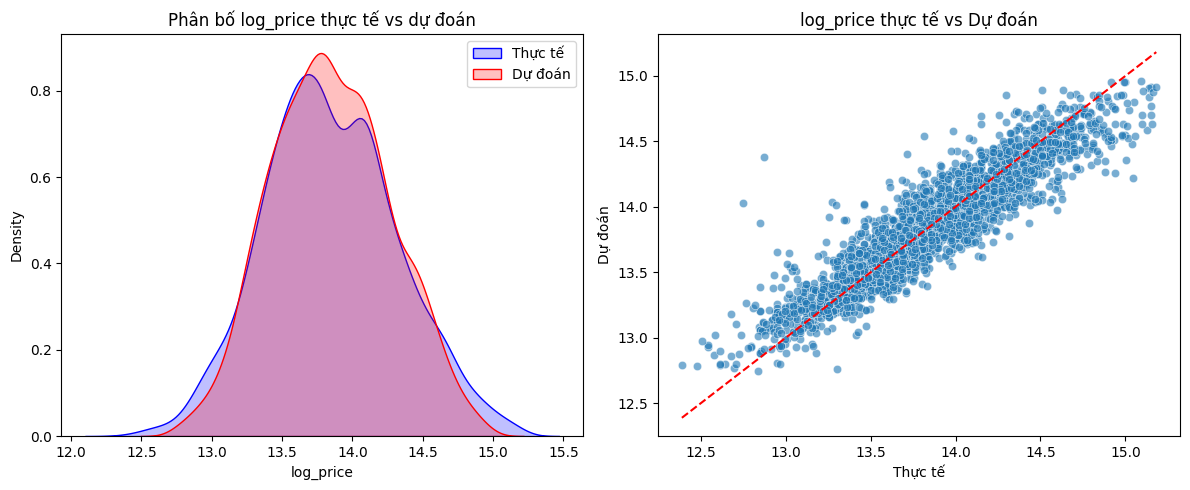

In [5]:
# 1. Trực quan hóa kết quả (Ta giữ log_price để tiện cho việc trực quan hóa)
plt.figure(figsize=(12, 5))

# Biểu đồ phân bố
plt.subplot(1, 2, 1)
sns.kdeplot(y_test, label="Thực tế", fill=True, color="blue")
sns.kdeplot(y_pred, label="Dự đoán", fill=True, color="red")
plt.title("Phân bố log_price thực tế vs dự đoán")
plt.xlabel("log_price")
plt.legend()

# Biểu đồ scatter
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.title("log_price thực tế vs Dự đoán")
plt.xlabel("Thực tế")
plt.ylabel("Dự đoán")
plt.tight_layout()
plt.show()

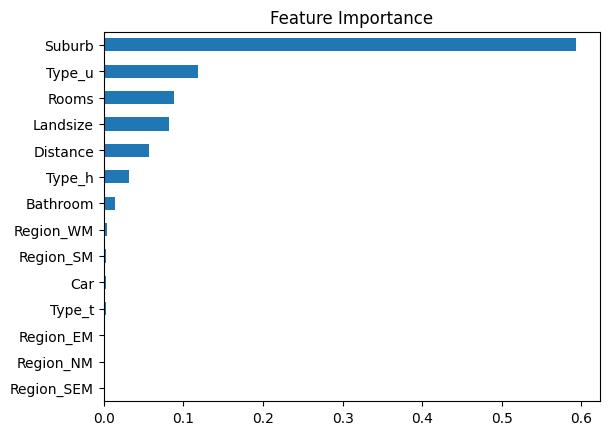

In [6]:
# 2. Important features:
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns)
feat_imp.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

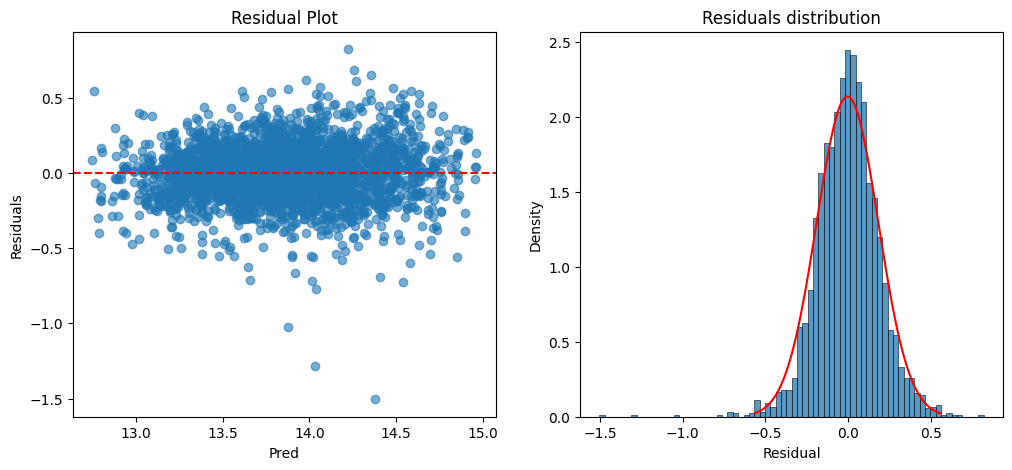

In [7]:
# 3. Biểu đồ phần dư
residuals = y_test - y_pred

plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Pred")
plt.ylabel("Residuals")
plt.title("Residual Plot")

# Phân bố phần dư
plt.subplot(1, 2, 2)
sns.histplot(residuals, stat="density")
# vẽ đường normal
mean = np.mean(residuals)
std = np.std(residuals)
x = np.linspace(mean - 3*std, mean + 3*std, 100)
y = (1/(std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean)/std)**2)
plt.plot(x, y, color='r')
plt.title("Residuals distribution")
plt.xlabel("Residual")
plt.show()

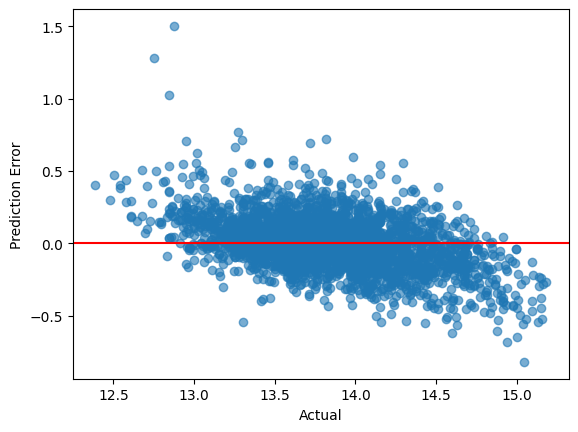

In [8]:
# 4. Prediction error plot
plt.scatter(y_test, y_pred - y_test, alpha=0.6)
plt.axhline(0, color="red")
plt.xlabel("Actual")
plt.ylabel("Prediction Error")
plt.show()

# Nhận xét:
- Nhìn vào các metric và phân bố dự đoán - thực tế, ta thấy mô hình có độ chính xác tương đối cao. Tuy nhiên, phân phối dự đoán bị kéo về trung bình, hẹp hơn so với phân bố thật.
- Nhận thấy yếu tố ảnh hưởng lớn đến giá trị của BĐS là khu vực địa lý. Ở bước 3, ta đã nhìn ra xu hướng đó
- Residual phân bố ngẫu nhiên quanh giá trị 0, theo phân phối chuẩn. Chỉ ra mô hình fit với data
- Một điểm đáng chú ý của Pred Error plot: có xu hướng âm (Nâng giá thấp, hạ giá cao) hay chính là đang kéo về hướng mean.